In [2]:
import glob
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Buscar automáticamente todos los archivos CSV de tus semillas
archivos_csv = sorted(glob.glob('linear_taylor_pid_results_sinusoidal_*.csv'))

# Si prefieres declararlos de forma explícita manualmente:
# archivos_csv = ['resultados_control_pinn_semilla_1.csv', 'resultados_control_pinn_semilla_2.csv', ...]

lista_metricas_globales = []

# 2. Bucle para calcular métricas unificadas por cada simulación
for archivo in archivos_csv:
    df = pd.read_csv(archivo)
    
    # Errores puntuales para h1 y h2
    #e1 = df['h1_pinn_nmpc'] - df['h1_ref']
    #e2 = df['h2_pinn_nmpc'] - df['h2_ref']
    e1 = df['h1_real_pid'] - df['h1_ref']
    e2 = df['h2_real_pid'] - df['h2_ref']
    
    # --- Cálculos Base Individuales ---
    sse_h1 = np.sum(e1**2)
    sse_h2 = np.sum(e2**2)
    
    rmse_h1 = np.sqrt(np.mean(e1**2))
    rmse_h2 = np.sqrt(np.mean(e2**2))
    
    rango_h1 = df['h1_ref'].max() - df['h1_ref'].min()
    rango_h2 = df['h2_ref'].max() - df['h2_ref'].min()
    
    factor_norm_h1 = rango_h1 if rango_h1 != 0 else df['h1_ref'].mean()
    factor_norm_h2 = rango_h2 if rango_h2 != 0 else df['h2_ref'].mean()
    
    nrmse_h1 = rmse_h1 / factor_norm_h1
    nrmse_h2 = rmse_h2 / factor_norm_h2
    
    # --- Aplicación de Condiciones Globales por Simulación ---
    sse_global = sse_h1 + sse_h2               # Se SUMAN
    rmse_global = (rmse_h1 + rmse_h2) / 2      # Se PROMEDIAN
    nrmse_global = (nrmse_h1 + nrmse_h2) / 2    # Se PROMEDIAN
    
    # Almacenar métricas globales del archivo actual
    lista_metricas_globales.append({
        'Archivo': archivo,
        'SSE_Global': sse_global,
        'RMSE_Global': rmse_global,
        'NRMSE_Global': nrmse_global
    })

# Convertimos a DataFrame para procesar la estadística descriptiva del sistema
df_metricas_sistema = pd.DataFrame(lista_metricas_globales)


# 3. Cálculo de los Intervalos de Confianza (95%) sobre las Métricas Globales
resumen_estadistico_global = []
columnas_globales = ['SSE_Global', 'RMSE_Global', 'NRMSE_Global']

confianza = 0.99
n_muestras = len(df_metricas_sistema)
grados_libertad = n_muestras - 1

for col in columnas_globales:
    datos_metrica = df_metricas_sistema[col]
    
    media = np.mean(datos_metrica)
    desviacion_std = np.std(datos_metrica, ddof=1) # ddof=1 muestra corregida
    error_estandar = stats.sem(datos_metrica)      # Error estándar de la media
    
    # Margen de error usando t-Student para N=10 (o longitud dinámica de tus archivos)
    margen_error = error_estandar * stats.t.ppf((1 + confianza) / 2., grados_libertad)
    
    resumen_estadistico_global.append({
        'Métrica Global': col,
        'Media': round(media, 4),
        'Desviación Estándar': round(desviacion_std, 4),
        'IC_99%_Inferior': round(media - margen_error, 4),
        'IC_99%_Superior': round(media + margen_error, 4),
        'Margen_Error': round(margen_error, 4)
    })

# 4. Convertir a DataFrame final y guardar el resumen consolidado
df_resumen_final = pd.DataFrame(resumen_estadistico_global)
df_resumen_final.to_csv('linear_taylor_pid_sinusoidal_metrics_ic_99.csv', index=False)

print("\n" + "="*75)
print("     RESUMEN ESTADÍSTICO E INTERVALOS DE CONFIANZA DEL SISTEMA (99%)")
print("="*75)
print(df_resumen_final.to_string(index=False))
print("="*75)


     RESUMEN ESTADÍSTICO E INTERVALOS DE CONFIANZA DEL SISTEMA (99%)
Métrica Global    Media  Desviación Estándar  IC_99%_Inferior  IC_99%_Superior  Margen_Error
    SSE_Global 238.9340               2.2644         236.6069         241.2610        2.3271
   RMSE_Global   0.1207               0.0006           0.1201           0.1213        0.0006
  NRMSE_Global   0.0201               0.0001           0.0200           0.0202        0.0001


In [13]:
import glob
import numpy as np
import pandas as pd
import scipy.stats as stats

sim_type = 'step'
control_type = 'pinn_nmpc'

# 1. Buscar automáticamente todos los archivos CSV de rendimiento de Koopman
archivos_csv = sorted(glob.glob('performance_metrics_' + control_type + '_' + sim_type + '_*.csv'))

lista_rtf = []

# 2. Bucle para extraer el RTF de cada simulación (estructura vertical Metric/Value)
for archivo in archivos_csv:
    df = pd.read_csv(archivo)
    
    # Limpiamos strings por si acaso hay espacios en blanco en los nombres de las columnas
    df.columns = df.columns.str.strip()
    
    # Buscamos la fila donde la columna 'Metric' sea exactamente 'Real-Time Factor (RTF)'
    fila_rtf = df[df['Metric'].str.strip() == 'Real-Time Factor (RTF)']
    
    if not fila_rtf.empty:
        # Extraemos el valor y lo convertimos a flotante
        val_rtf = float(fila_rtf['Value'].values[0])
        lista_rtf.append({
            'Archivo': archivo,
            'RTF': val_rtf
        })
    else:
        print(f"Advertencia: No se encontró la métrica 'Real-Time Factor (RTF)' en {archivo}")

# Convertimos a DataFrame para procesar la estadística descriptiva
df_rtf_sistema = pd.DataFrame(lista_rtf)

# Validar que encontramos datos antes de calcular estadísticas
if len(df_rtf_sistema) > 0:
    
    # 3. Cálculo de los Intervalos de Confianza (99%) sobre el RTF
    confianza = 0.99
    n_muestras = len(df_rtf_sistema)
    grados_libertad = n_muestras - 1

    datos_rtf = df_rtf_sistema['RTF']
    
    media = np.mean(datos_rtf)
    desviacion_std = np.std(datos_rtf, ddof=1)  # Muestra corregida (ddof=1)
    
    # Si solo hay 1 archivo, el error estándar y el margen de error no se pueden calcular mediante t-Student
    if n_muestras > 1:
        error_estandar = stats.sem(datos_rtf)
        margen_error = error_estandar * stats.t.ppf((1 + confianza) / 2., grados_libertad)
        ic_inferior = media - margen_error
        ic_superior = media + margen_error
    else:
        error_estandar = 0.0
        margen_error = 0.0
        ic_inferior = media
        ic_superior = media

    resumen_rtf = [{
        'Métrica': 'Real-Time Factor (RTF)',
        'Media': round(media, 4),
        'Desviación Estándar': round(desviacion_std, 4) if n_muestras > 1 else 0.0,
        'IC_99%_Inferior': round(ic_inferior, 4),
        'IC_99%_Superior': round(ic_superior, 4),
        'Margen_Error': round(margen_error, 4)
    }]

    # 4. Convertir a DataFrame final y guardar el resumen consolidado
    df_resumen_final = pd.DataFrame(resumen_rtf)
    df_resumen_final.to_csv(f'{control_type}_{sim_type}_rtf_ic_99.csv', index=False)

    print("\n" + "="*75)
    print("     RESUMEN ESTADÍSTICO E INTERVALOS DE CONFIANZA DEL RTF (99%)")
    print("="*75)
    print(df_resumen_final.to_string(index=False))
    print("="*75)
    print(f"Procesados correctamente {n_muestras} archivo(s).")
    
else:
    print("No se encontraron datos válidos para procesar.")


     RESUMEN ESTADÍSTICO E INTERVALOS DE CONFIANZA DEL RTF (99%)
               Métrica  Media  Desviación Estándar  IC_99%_Inferior  IC_99%_Superior  Margen_Error
Real-Time Factor (RTF) 10.777               0.0633           10.712           10.842         0.065
Procesados correctamente 10 archivo(s).


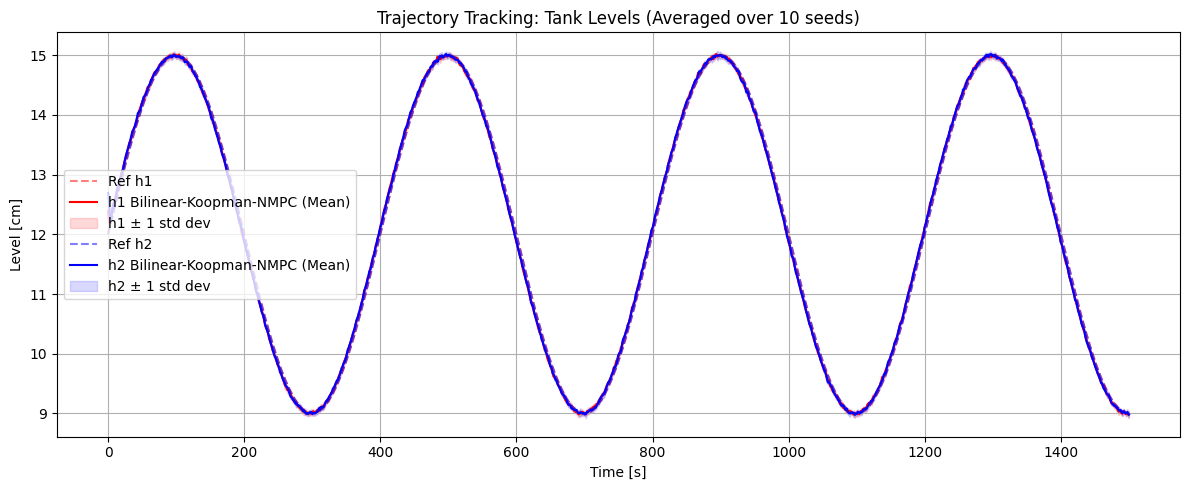

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Buscar de forma dinámica los 10 archivos CSV
archivos_csv = sorted(glob.glob('bilinear_koopman_nmpc_results_sinusoidal_*.csv'))

# Listas para almacenar las curvas temporales de cada ejecución
h1_experimentos = []
h2_experimentos = []
v1_experimentos = []
v2_experimentos = []

# Extraemos la línea temporal y las referencias fijas del primer archivo
df_base = pd.read_csv(archivos_csv[0])
t_test = df_base['Time_s'].values
h1_ref = df_base['h1_ref'].values
h2_ref = df_base['h2_ref'].values

# Cargar los datos ordenados de todas las ejecuciones
for archivo in archivos_csv:
    df = pd.read_csv(archivo)
    #h1_experimentos.append(df['h1_pinn_nmpc'].values)
    #h2_experimentos.append(df['h2_pinn_nmpc'].values)
    h1_experimentos.append(df['h1_bilinear_koopman_nmpc'].values)
    h2_experimentos.append(df['h2_bilinear_koopman_nmpc'].values)
    v1_experimentos.append(df['v1_pump'].values)
    v2_experimentos.append(df['v2_pump'].values)

# 2. Calcular los promedios temporales punto a punto (eje de las ejecuciones = 0)
h1_mean = np.mean(h1_experimentos, axis=0)
h2_mean = np.mean(h2_experimentos, axis=0)
v1_mean = np.mean(v1_experimentos, axis=0)
v2_mean = np.mean(v2_experimentos, axis=0)

# Calcular desviaciones estándar puntuales para sombrear la variabilidad
h1_std = np.std(h1_experimentos, axis=0)
h2_std = np.std(h2_experimentos, axis=0)


# --- GRÁFICA 1: SEGUIMIENTO DE TRAYECTORIA (NIVELES h1 Y h2) ---
plt.figure(figsize=(12, 5))

# Tanque 1: Referencia, Promedio y Sombra de variabilidad (±1 Desviación Estándar)
plt.plot(t_test, h1_ref, 'r--', alpha=0.5, label='Ref h1')
plt.plot(t_test, h1_mean, 'r', label='h1 Bilinear-Koopman-NMPC (Mean)')
plt.fill_between(t_test, h1_mean - h1_std, h1_mean + h1_std, color='r', alpha=0.15, label='h1 ± 1 std dev')

# Tanque 2: Referencia, Promedio y Sombra de variabilidad (±1 Desviación Estándar)
plt.plot(t_test, h2_ref, 'b--', alpha=0.5, label='Ref h2')
plt.plot(t_test, h2_mean, 'b', label='h2 Bilinear-Koopman-NMPC (Mean)')
plt.fill_between(t_test, h2_mean - h2_std, h2_mean + h2_std, color='b', alpha=0.15, label='h2 ± 1 std dev')

plt.title('Trajectory Tracking: Tank Levels (Averaged over 10 seeds)')
plt.xlabel('Time [s]')
plt.ylabel('Level [cm]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

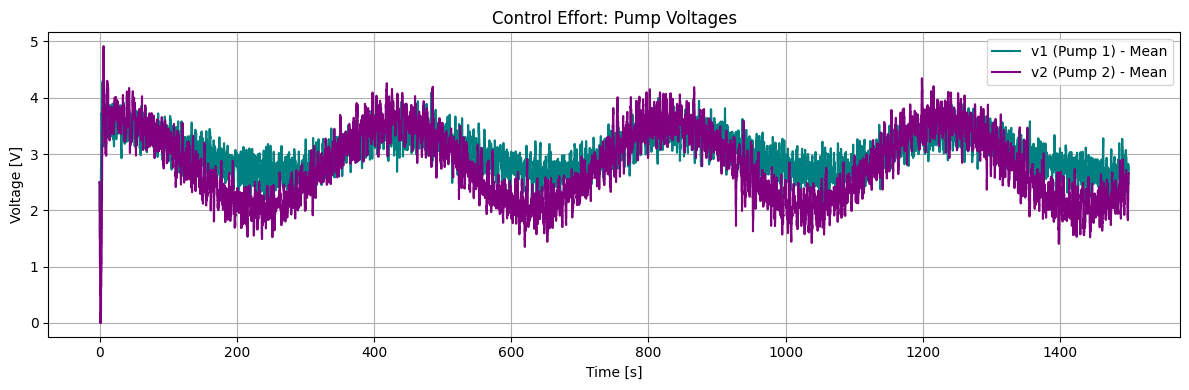

In [2]:
# --- GRÁFICA 2: ESFUERZO DE CONTROL (VOLTAJES v1 Y v2) ---
plt.figure(figsize=(12, 4))

plt.step(t_test, v1_mean, label='v1 (Pump 1) - Mean', where='mid', color='teal')
plt.step(t_test, v2_mean, label='v2 (Pump 2) - Mean', where='mid', color='purple')

plt.title('Control Effort: Pump Voltages')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

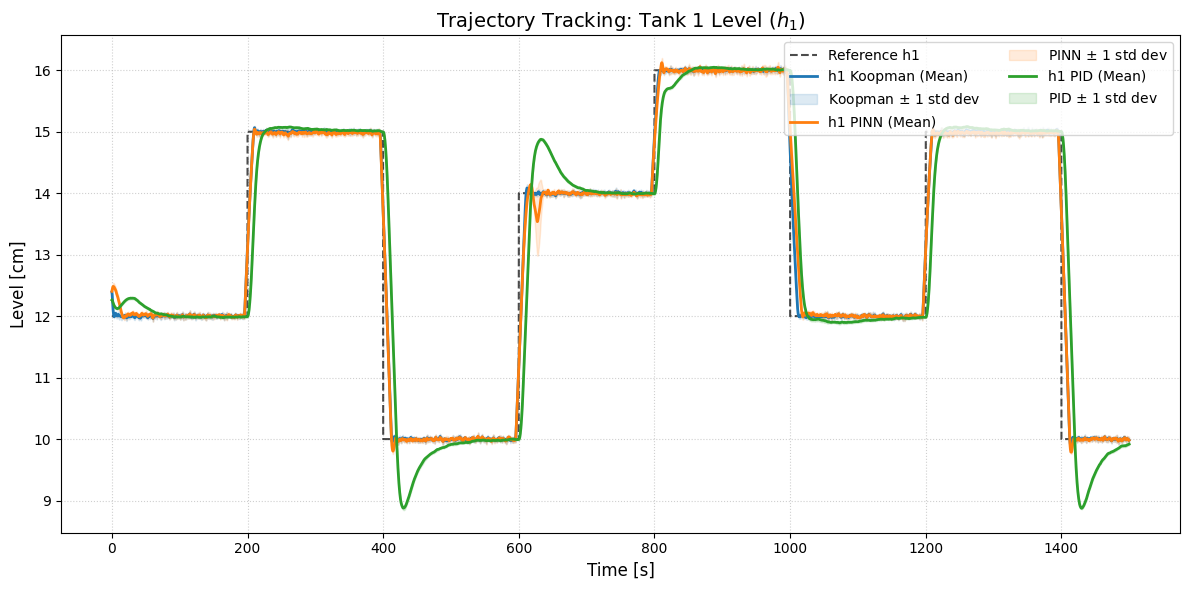

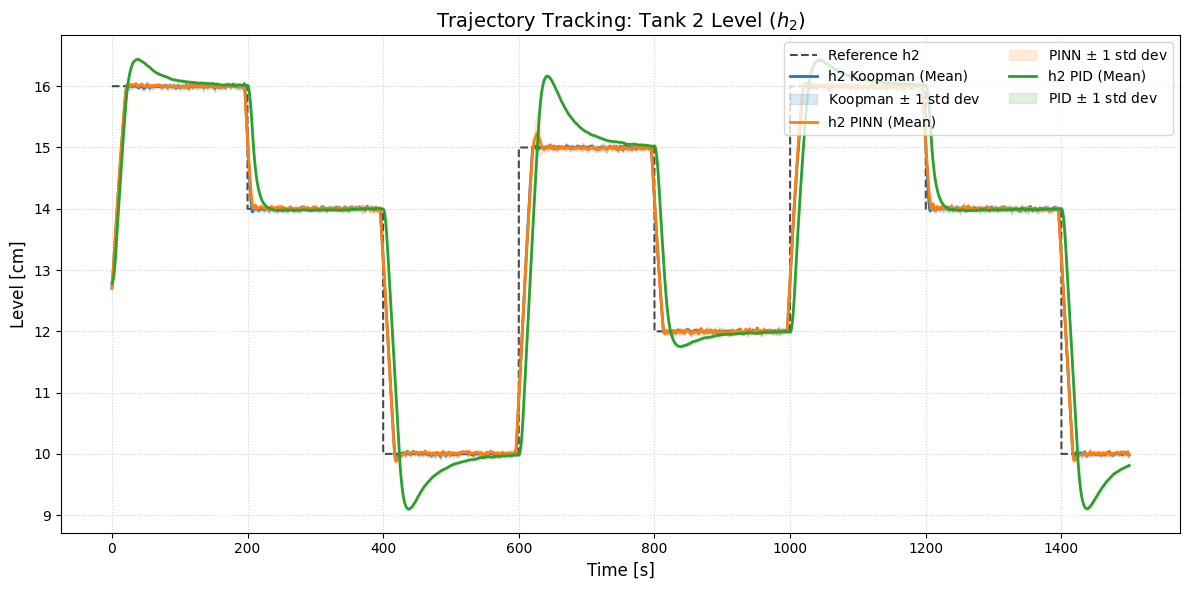

In [6]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

reference_type = 'step'

# ==========================================
# 1. BÚSQUEDA DINÁMICA DE ARCHIVOS CSV
# ==========================================
archivos_koopman = sorted(glob.glob('bilinear_koopman_nmpc_results_' + reference_type + '_*.csv'))
archivos_pinn    = sorted(glob.glob('pinn_nmpc_results_' + reference_type + '_*.csv'))
archivos_pid     = sorted(glob.glob('linear_taylor_pid_results_' + reference_type + '_*.csv'))

# Diccionario para automatizar la extracción de datos según el archivo
config_metodos = {
    'Koopman': {
        'archivos': archivos_koopman,
        'col_h1': 'h1_bilinear_koopman_nmpc',
        'col_h2': 'h2_bilinear_koopman_nmpc'
    },
    'PINN': {
        'archivos': archivos_pinn,
        'col_h1': 'h1_pinn_nmpc',
        'col_h2': 'h2_pinn_nmpc'
    },
    'PID': {
        'archivos': archivos_pid,
        'col_h1': 'h1_real_pid',
        'col_h2': 'h2_real_pid'
    }
}

# Extraemos la línea temporal y las referencias usando el primer archivo disponible
df_base = pd.read_csv(archivos_koopman[0])
t_test = df_base['Time_s'].values
h1_ref = df_base['h1_ref'].values
h2_ref = df_base['h2_ref'].values

# Contenedor para los resultados estadísticos finales
stats = {}

# ==========================================
# 2. PROCESAMIENTO DE DATOS Y ESTADÍSTICAS
# ==========================================
for metodo, config in config_metodos.items():
    h1_exp = []
    h2_exp = []
    
    for archivo in config['archivos']:
        df = pd.read_csv(archivo)
        # Se añade [:len(t_test)] para truncar cualquier fila extra y acoplar las dimensiones
        h1_exp.append(df[config['col_h1']].values[:len(t_test)])
        h2_exp.append(df[config['col_h2']].values[:len(t_test)])
        
    stats[metodo] = {
        'h1_mean': np.mean(h1_exp, axis=0),
        'h1_std':  np.std(h1_exp, axis=0),
        'h2_mean': np.mean(h2_exp, axis=0),
        'h2_std':  np.std(h2_exp, axis=0)
    }

# Paleta de colores para mantener coherencia estética
colores = {
    'Koopman': {'linea': '#1f77b4', 'sombra': '#1f77b4'},  # Azul
    'PINN':    {'linea': '#ff7f0e', 'sombra': '#ff7f0e'},  # Naranja
    'PID':     {'linea': '#2ca02c', 'sombra': '#2ca02c'}   # Verde
}

# ==========================================
# 3. VISUALIZACIÓN POR SEPARADO (POR TANQUE)
# ==========================================

# --- GRÁFICA TANQUE 1 (h1) ---
plt.figure(figsize=(12, 6))
# Referencia del Tanque 1
plt.plot(t_test, h1_ref, 'k--', alpha=0.7, linewidth=1.5, label='Reference h1')

# Curvas para cada método
for metodo, datos in stats.items():
    plt.plot(t_test, datos['h1_mean'], color=colores[metodo]['linea'], 
             linewidth=2, label=f'h1 {metodo} (Mean)')
    plt.fill_between(t_test, datos['h1_mean'] - datos['h1_std'], datos['h1_mean'] + datos['h1_std'], 
                     color=colores[metodo]['sombra'], alpha=0.15, label=f'{metodo} $\pm$ 1 std dev')

plt.title('Trajectory Tracking: Tank 1 Level ($h_1$)', fontsize=14)
plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Level [cm]', fontsize=12)
plt.legend(loc='upper right', ncol=2)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# --- GRÁFICA TANQUE 2 (h2) ---
plt.figure(figsize=(12, 6))
# Referencia del Tanque 2
plt.plot(t_test, h2_ref, 'k--', alpha=0.7, linewidth=1.5, label='Reference h2')

# Curvas para cada método
for metodo, datos in stats.items():
    plt.plot(t_test, datos['h2_mean'], color=colores[metodo]['linea'], 
             linewidth=2, label=f'h2 {metodo} (Mean)')
    plt.fill_between(t_test, datos['h2_mean'] - datos['h2_std'], datos['h2_mean'] + datos['h2_std'], 
                     color=colores[metodo]['sombra'], alpha=0.15, label=f'{metodo} $\pm$ 1 std dev')

plt.title('Trajectory Tracking: Tank 2 Level ($h_2$)', fontsize=14)
plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Level [cm]', fontsize=12)
plt.legend(loc='upper right', ncol=2)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_95142/3379332204.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


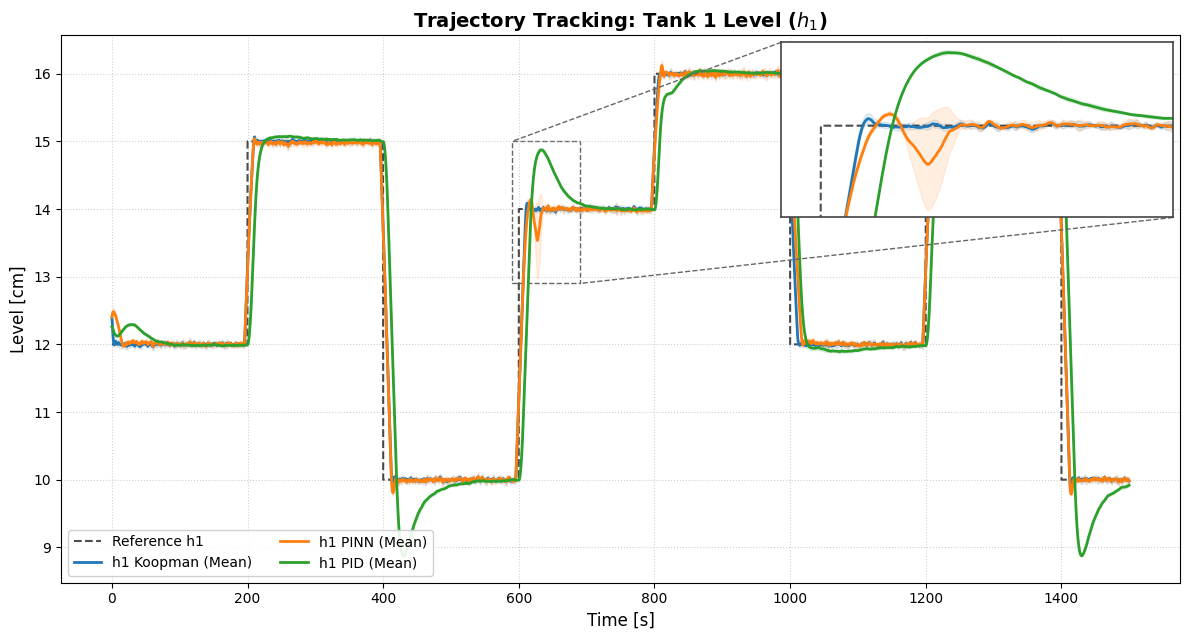

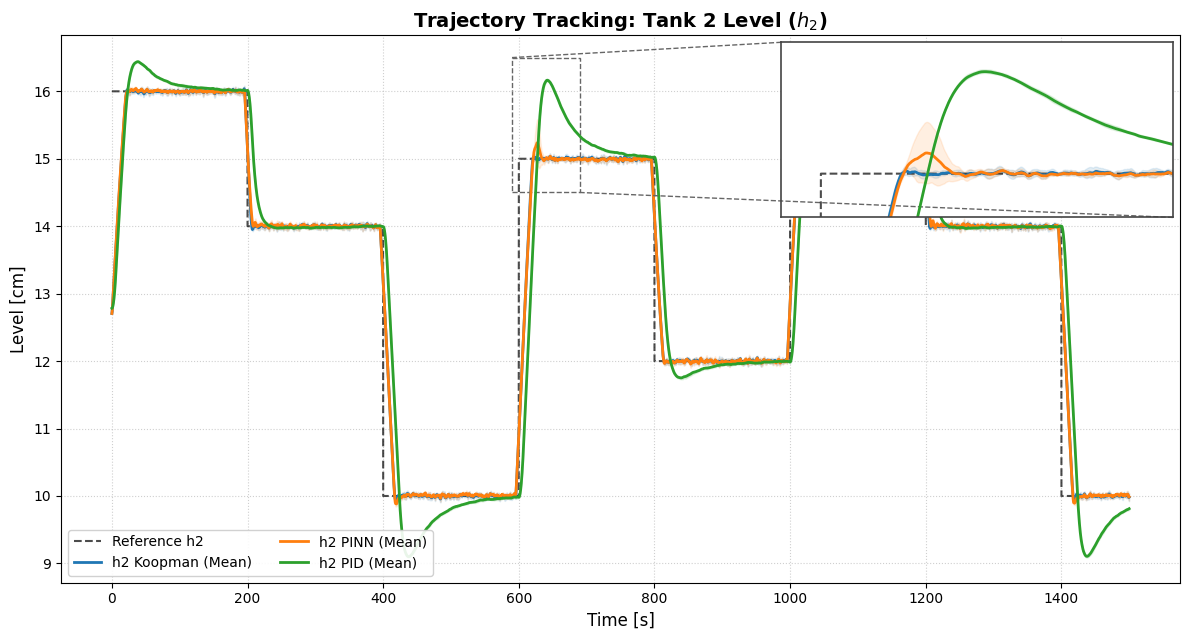

In [24]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Herramientas clave para el recuadro de zoom e indicadores
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

reference_type = 'step'

# ==========================================
# 1. BÚSQUEDA DINÁMICA DE ARCHIVOS CSV
# ==========================================
archivos_koopman = sorted(glob.glob('bilinear_koopman_nmpc_results_' + reference_type + '_*.csv'))
archivos_pinn    = sorted(glob.glob('pinn_nmpc_results_' + reference_type + '_*.csv'))
archivos_pid     = sorted(glob.glob('linear_taylor_pid_results_' + reference_type + '_*.csv'))

config_metodos = {
    'Koopman': {'archivos': archivos_koopman, 'col_h1': 'h1_bilinear_koopman_nmpc', 'col_h2': 'h2_bilinear_koopman_nmpc'},
    'PINN':    {'archivos': archivos_pinn,    'col_h1': 'h1_pinn_nmpc',    'col_h2': 'h2_pinn_nmpc'},
    'PID':     {'archivos': archivos_pid,     'col_h1': 'h1_real_pid',     'col_h2': 'h2_real_pid'}
}

df_base = pd.read_csv(archivos_koopman[0])
t_test = df_base['Time_s'].values
h1_ref = df_base['h1_ref'].values
h2_ref = df_base['h2_ref'].values

stats = {}

# ==========================================
# 2. PROCESAMIENTO DE DATOS Y ESTADÍSTICAS
# ==========================================
for metodo, config in config_metodos.items():
    h1_exp = []
    h2_exp = []
    for archivo in config['archivos']:
        df = pd.read_csv(archivo)
        h1_exp.append(df[config['col_h1']].values[:len(t_test)])
        h2_exp.append(df[config['col_h2']].values[:len(t_test)])
        
    stats[metodo] = {
        'h1_mean': np.mean(h1_exp, axis=0), 'h1_std': np.std(h1_exp, axis=0),
        'h2_mean': np.mean(h2_exp, axis=0), 'h2_std': np.std(h2_exp, axis=0)
    }

colores = {
    'Koopman': {'linea': '#1f77b4', 'sombra': '#1f77b4'},
    'PINN':    {'linea': '#ff7f0e', 'sombra': '#ff7f0e'},
    'PID':     {'linea': '#2ca02c', 'sombra': '#2ca02c'}
}

# ==========================================
# 3. FUNCIÓN DE GRAFICACIÓN CON INSET ZOOM MODIFICADO
# ==========================================
def graficar_con_lupa(id_tanque, t, ref, datos_stats, config_zoom=None):
    """
    config_zoom: dict con parámetros de la lupa:
                 { 'xlim': (t_min, t_max), 'ylim': (y_min, y_max), 'width': "30%", 'height': "30%", 'loc': 1 }
    """
    fig, ax = plt.subplots(figsize=(12, 6.5))
    
    # --- Gráfica Principal ---
    ax.plot(t, ref, 'k--', alpha=0.7, linewidth=1.5, label=f'Reference h{id_tanque}')
    for metodo, datos in datos_stats.items():
        mean_key, std_key = f'h{id_tanque}_mean', f'h{id_tanque}_std'
        ax.plot(t, datos[mean_key], color=colores[metodo]['linea'], linewidth=2, label=f'h{id_tanque} {metodo} (Mean)')
        ax.fill_between(t, datos[mean_key] - datos[std_key], datos[mean_key] + datos[std_key], 
                        color=colores[metodo]['sombra'], alpha=0.12)

    ax.set_title(f'Trajectory Tracking: Tank {id_tanque} Level ($h_{id_tanque}$)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time [s]', fontsize=12)
    ax.set_ylabel('Level [cm]', fontsize=12)
    ax.legend(loc='lower left', ncol=2, frameon=True, facecolor='white', framealpha=0.9)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # --- Construcción de la Lupa Integrada ---
    if config_zoom is not None:
        from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
        
        # 1. Definimos el tamaño de la lupa de forma porcentual respecto a la gráfica principal (Nunca será mayor)
        ax_inset = inset_axes(ax, 
                              width=config_zoom['width'],   # Ejemplo: "35%" del ancho de la gráfica madre
                              height=config_zoom['height'], # Ejemplo: "30%" del alto de la gráfica madre
                              loc=config_zoom['loc'])
        
        # Re-graficamos el contenido dentro de la lupa
        ax_inset.plot(t, ref, 'k--', alpha=0.7, linewidth=1.5)
        for metodo, datos in datos_stats.items():
            mean_key, std_key = f'h{id_tanque}_mean', f'h{id_tanque}_std'
            ax_inset.plot(t, datos[mean_key], color=colores[metodo]['linea'], linewidth=2)
            ax_inset.fill_between(t, datos[mean_key] - datos[std_key], datos[mean_key] + datos[std_key], 
                                  color=colores[metodo]['sombra'], alpha=0.12)
        
        # Encuadrar la sección crítica requerida
        ax_inset.set_xlim(config_zoom['xlim'])
        ax_inset.set_ylim(config_zoom['ylim'])
        
        # 2. Remover por completo los ejes y detalles (etiquetas de números flotantes)
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
        ax_inset.set_xticklabels([])
        ax_inset.set_yticklabels([])
        
        # Mantener la cuadrícula de fondo interna para no perder la referencia visual del trazo
        ax_inset.grid(True, linestyle=':', alpha=0.5)
        
        # Cambiar el color o grosor del borde de la lupa si lo deseas (opcional)
        for spine in ax_inset.spines.values():
            spine.set_edgecolor('#444444')
            spine.set_linewidth(1.2)
        
        # Dibujar líneas conectoras discontinuas desde la región original a la lupa
        mark_inset(ax, ax_inset, loc1=2, loc2=4, fc="none", ec="0.4", linestyle="--", linewidth=1)

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. CONFIGURACIÓN DEL TRASLAPE Y RENDER
# ==========================================

# Parámetros explícitos de dimensiones porcentuales
opciones_zoom_h1 = {
    'xlim': (590, 690),       # Sección del transitorio/paso
    'ylim': (12.9, 15.0),     
    'width': "35%",           # Ancho controlado de la lupa respecto al lienzo principal
    'height': "32%",          # Alto controlado de la lupa respecto al lienzo principal
    'loc': 1                  # 1 = Arriba a la derecha
}

opciones_zoom_h2 = {
    'xlim': (590, 690),
    'ylim': (14.5, 16.5),
    'width': "35%",
    'height': "32%",
    'loc': 1
}

# Ejecutar render
graficar_con_lupa(id_tanque=1, t=t_test, ref=h1_ref, datos_stats=stats, config_zoom=opciones_zoom_h1)
graficar_con_lupa(id_tanque=2, t=t_test, ref=h2_ref, datos_stats=stats, config_zoom=opciones_zoom_h2)

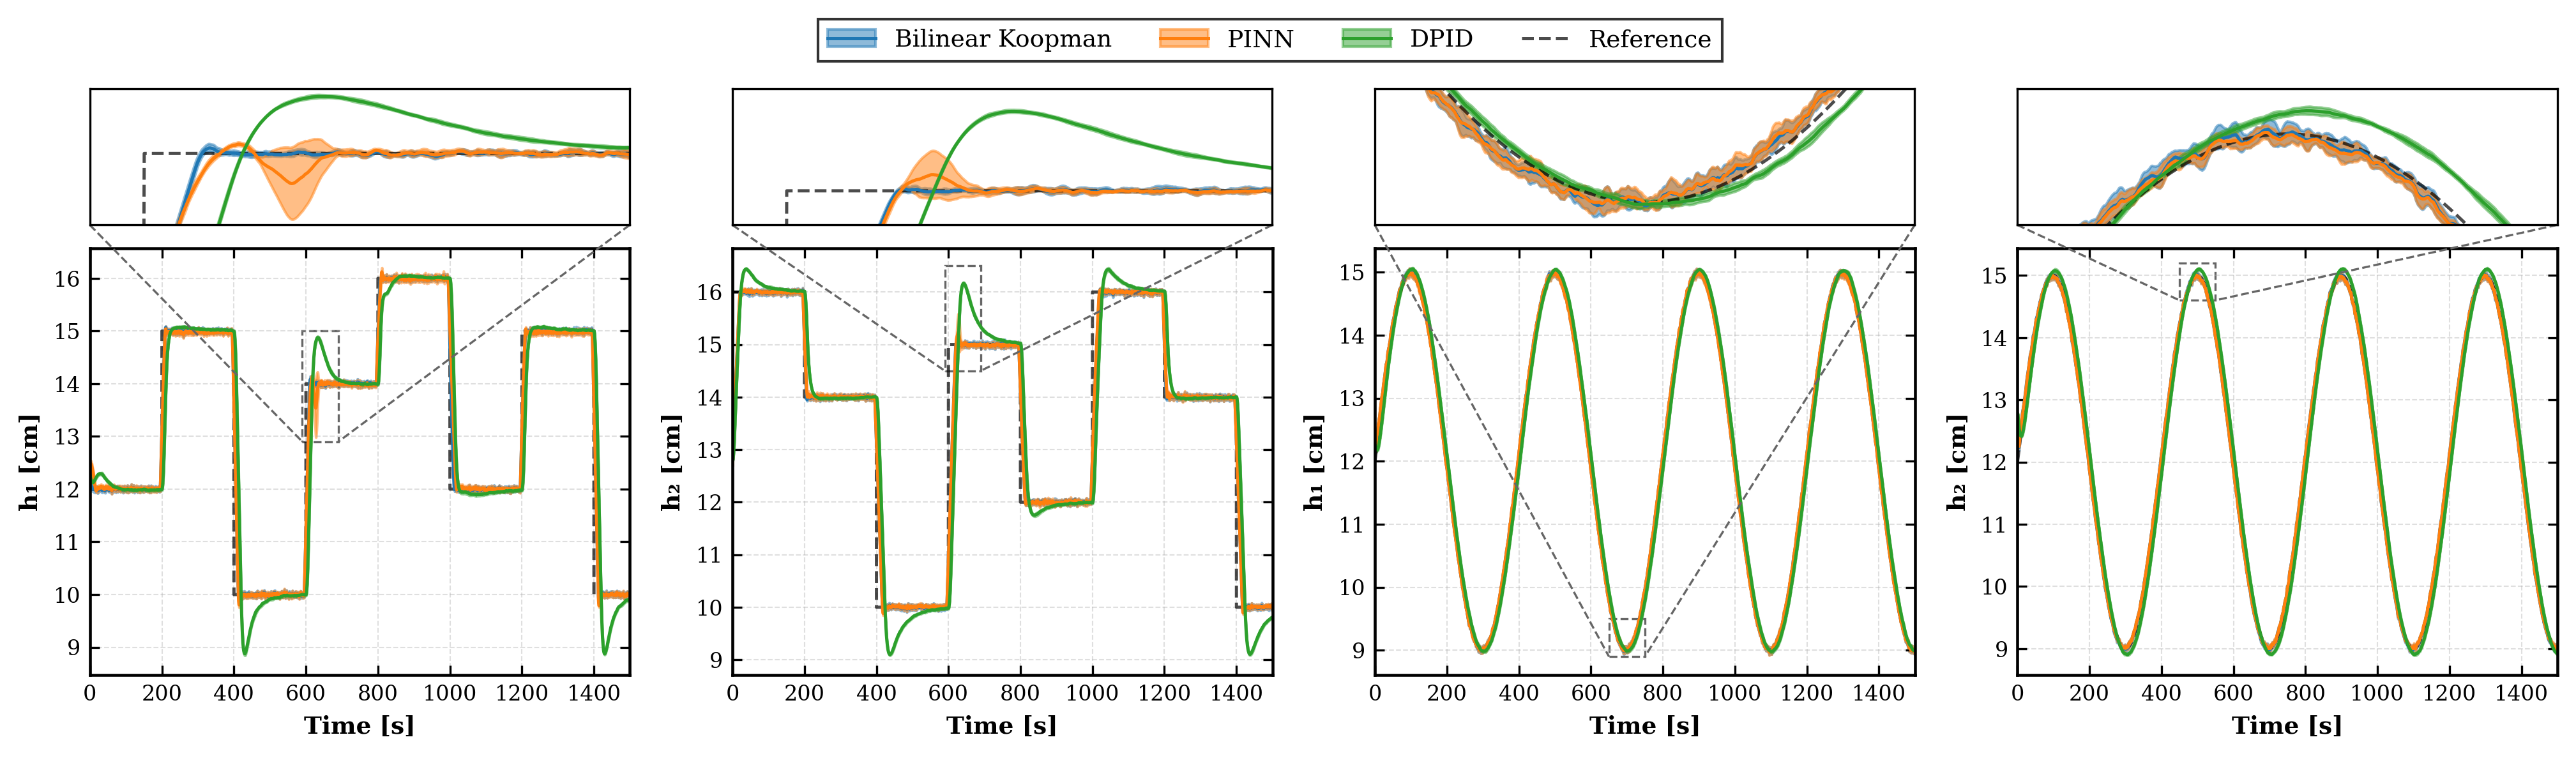

In [33]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ==========================================
# CONFIGURACIÓN ESTILO IEEE
# ==========================================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.linewidth": 1.1,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.0
})

# Mapeo explícito para las 4 columnas consecutivas de la fila única
# Cada tupla contiene: (índice de columna, tipo de referencia, ID de tanque interno, etiqueta Y)
config_columnas = [
    (0, 'step', 1, 'h₁ [cm]'),
    (1, 'step', 2, 'h₂ [cm]'),
    (2, 'sinusoidal', 1, 'h₁ [cm]'),
    (3, 'sinusoidal', 2, 'h₂ [cm]')
]

colores = {
    'Koopman': {'linea': '#1f77b4', 'sombra': '#1f77b4'},  # Azul
    'PINN':    {'linea': '#ff7f0e', 'sombra': '#ff7f0e'},  # Naranja
    'DPID':    {'linea': '#2ca02c', 'sombra': '#2ca02c'}   # Verde
}

# ==========================================
# 1. PROCESAMIENTO GLOBAL DE DATOS
# ==========================================
datos_completos = {}
tipos_referencia = ['step', 'sinusoidal']

for ref_type in tipos_referencia:
    archivos_koopman = sorted(glob.glob(f'bilinear_koopman_nmpc_results_{ref_type}_*.csv'))
    archivos_pinn    = sorted(glob.glob(f'pinn_nmpc_results_{ref_type}_*.csv'))
    archivos_pid     = sorted(glob.glob(f'linear_taylor_pid_results_{ref_type}_*.csv'))

    config_metodos = {
        'Koopman': {'archivos': archivos_koopman, 'col_h1': 'h1_bilinear_koopman_nmpc', 'col_h2': 'h2_bilinear_koopman_nmpc'},
        'PINN':    {'archivos': archivos_pinn,    'col_h1': 'h1_pinn_nmpc',    'col_h2': 'h2_pinn_nmpc'},
        'DPID':    {'archivos': archivos_pid,     'col_h1': 'h1_real_pid',     'col_h2': 'h2_real_pid'}
    }

    df_base = pd.read_csv(archivos_koopman[0])
    t_test = df_base['Time_s'].values
    h1_ref = df_base['h1_ref'].values
    h2_ref = df_base['h2_ref'].values

    stats = {}
    for metodo, config in config_metodos.items():
        h1_exp, h2_exp = [], []
        for archivo in config['archivos']:
            df = pd.read_csv(archivo)
            h1_exp.append(df[config['col_h1']].values[:len(t_test)])
            h2_exp.append(df[config['col_h2']].values[:len(t_test)])
            
        stats[metodo] = {
            'h1_mean': np.mean(h1_exp, axis=0), 'h1_std': np.std(h1_exp, axis=0),
            'h2_mean': np.mean(h2_exp, axis=0), 'h2_std': np.std(h2_exp, axis=0)
        }
        
    datos_completos[ref_type] = {
        't_test': t_test, 'h1_ref': h1_ref, 'h2_ref': h2_ref, 'stats': stats
    }

# ==========================================
# 2. CONFIGURACIÓN DE LUPAS (PROYECTADAS HACIA AFUERA)
# ==========================================
# Modificado para usar bbox_to_anchor de modo que se ubiquen en el exterior superior
config_lupas = {
    'step': {
        1: {'xlim': (590, 690), 'ylim': (12.9, 15.0), 'width': "100%", 'height': "32%", 'bbox': (-0.02, 1.03, 1.0, 1.0)},
        2: {'xlim': (590, 690), 'ylim': (14.5, 16.5), 'width': "100%", 'height': "32%", 'bbox': (-0.02, 1.03, 1.0, 1.0)}
    },
    'sinusoidal': {
        1: {'xlim': (650, 750), 'ylim': (8.9, 9.5),  'width': "100%", 'height': "32%", 'bbox': (-0.02, 1.03, 1.0, 1.0)},
        2: {'xlim': (450, 550), 'ylim': (14.6, 15.2), 'width': "100%", 'height': "32%", 'bbox': (-0.02, 1.03, 1.0, 1.0)}
    }
}

# ==========================================
# 3. GENERACIÓN DE LA MATRIZ DE GRÁFICAS 1x4
# ==========================================
# Se declara una sola fila (1, 4) compartiendo el eje X para homogeneidad absoluta
fig, axs = plt.subplots(1, 4, figsize=(14, 4.2), sharex=True, dpi=300)

line_handles = {}
shadow_handles = {}

for col_idx, ref_type, id_tanque, ylabel in config_columnas:
    ax = axs[col_idx]
    data_ctx = datos_completos[ref_type]
    t = data_ctx['t_test']
    
    ref_signal = data_ctx['h1_ref'] if id_tanque == 1 else data_ctx['h2_ref']
    stats_metodos = data_ctx['stats']
    
    # --- Gráfica Principal ---
    h_ref, = ax.plot(t, ref_signal, 'k--', alpha=0.7, linewidth=1.2)
    line_handles['Reference'] = h_ref
    
    for metodo, datos in stats_metodos.items():
        mean_key = f'h{id_tanque}_mean'
        std_key  = f'h{id_tanque}_std'
        
        h_line, = ax.plot(t, datos[mean_key], color=colores[metodo]['linea'], linewidth=1.2)
        h_shadow = ax.fill_between(t, datos[mean_key] - datos[std_key], datos[mean_key] + datos[std_key], 
                                   color=colores[metodo]['sombra'], alpha=0.50)
        
        label_name = 'Bilinear Koopman' if metodo == 'Koopman' else ('DPID' if metodo == 'DPID' else 'PINN')
        line_handles[label_name] = h_line
        shadow_handles[label_name] = h_shadow

    # Formateo de rejilla y límites internos estilo IEEE
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    ax.tick_params(direction='in', top=True, right=True)
    ax.set_xlim(0, 1500)
    
    # Textos y títulos individuales por columna
    ax.set_title(f"Tank {id_tanque}", fontsize=10, fontweight='bold', pad=48) # Pad alto para dar espacio a la lupa exterior
    ax.set_xlabel('Time [s]', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')

    # --- Inyección de Lupa Externa (Extruida del gráfico) ---
    zoom_cfg = config_lupas[ref_type][id_tanque]
    if zoom_cfg is not None:
        # Se inyecta usando el bbox_to_anchor para desplazar la caja sobre el techo de la subgráfica
        ax_inset = inset_axes(ax, width=zoom_cfg['width'], height=zoom_cfg['height'], 
                              bbox_to_anchor=zoom_cfg['bbox'], bbox_transform=ax.transAxes, loc='lower left')
        
        ax_inset.plot(t, ref_signal, 'k--', alpha=0.7, linewidth=1.2)
        for metodo, datos in stats_metodos.items():
            mean_key = f'h{id_tanque}_mean'
            std_key  = f'h{id_tanque}_std'
            ax_inset.plot(t, datos[mean_key], color=colores[metodo]['linea'], linewidth=1.2)
            ax_inset.fill_between(t, datos[mean_key] - datos[std_key], datos[mean_key] + datos[std_key], 
                                  color=colores[metodo]['sombra'], alpha=0.50)
        
        ax_inset.set_xlim(zoom_cfg['xlim'])
        ax_inset.set_ylim(zoom_cfg['ylim'])
        
        # Limpieza e indexación hacia adentro de la mini-gráfica
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
        ax_inset.set_xticklabels([])
        ax_inset.set_yticklabels([])
        ax_inset.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
        ax_inset.tick_params(direction='in', top=True, right=True)
        
        for spine in ax_inset.spines.values():
            spine.set_edgecolor("#000000")
            spine.set_linewidth(0.8)
        
        # Conectores discontinuos desde la gráfica base hasta la zona externa superior
        mark_inset(ax, ax_inset, loc1=3, loc2=4, fc="none", ec="0.4", linestyle="--", linewidth=0.8)

# Ajuste fino de subplots (Se incrementa sustancialmente el margen 'top' para acomodar la lupa externa y la leyenda)
plt.subplots_adjust(hspace=0.0, wspace=0.19, top=0.68, bottom=0.15, left=0.06, right=0.98)

# ==========================================
# 4. LEYENDA GLOBAL (MÁXIMO TECHO)
# ==========================================
legend_handles = [
    (line_handles['Bilinear Koopman'], shadow_handles['Bilinear Koopman']),
    (line_handles['PINN'], shadow_handles['PINN']),
    (line_handles['DPID'], shadow_handles['DPID']),
    line_handles['Reference']
]

legend_labels = ['Bilinear Koopman', 'PINN', 'DPID', 'Reference']

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.98),
    ncol=4,
    fontsize=9,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    fancybox=False
)

# Exportación directa en PDF vectorial lista para el archivo de LaTeX
plt.savefig('combined_control_results_1x4.pdf', bbox_inches='tight')
plt.show()

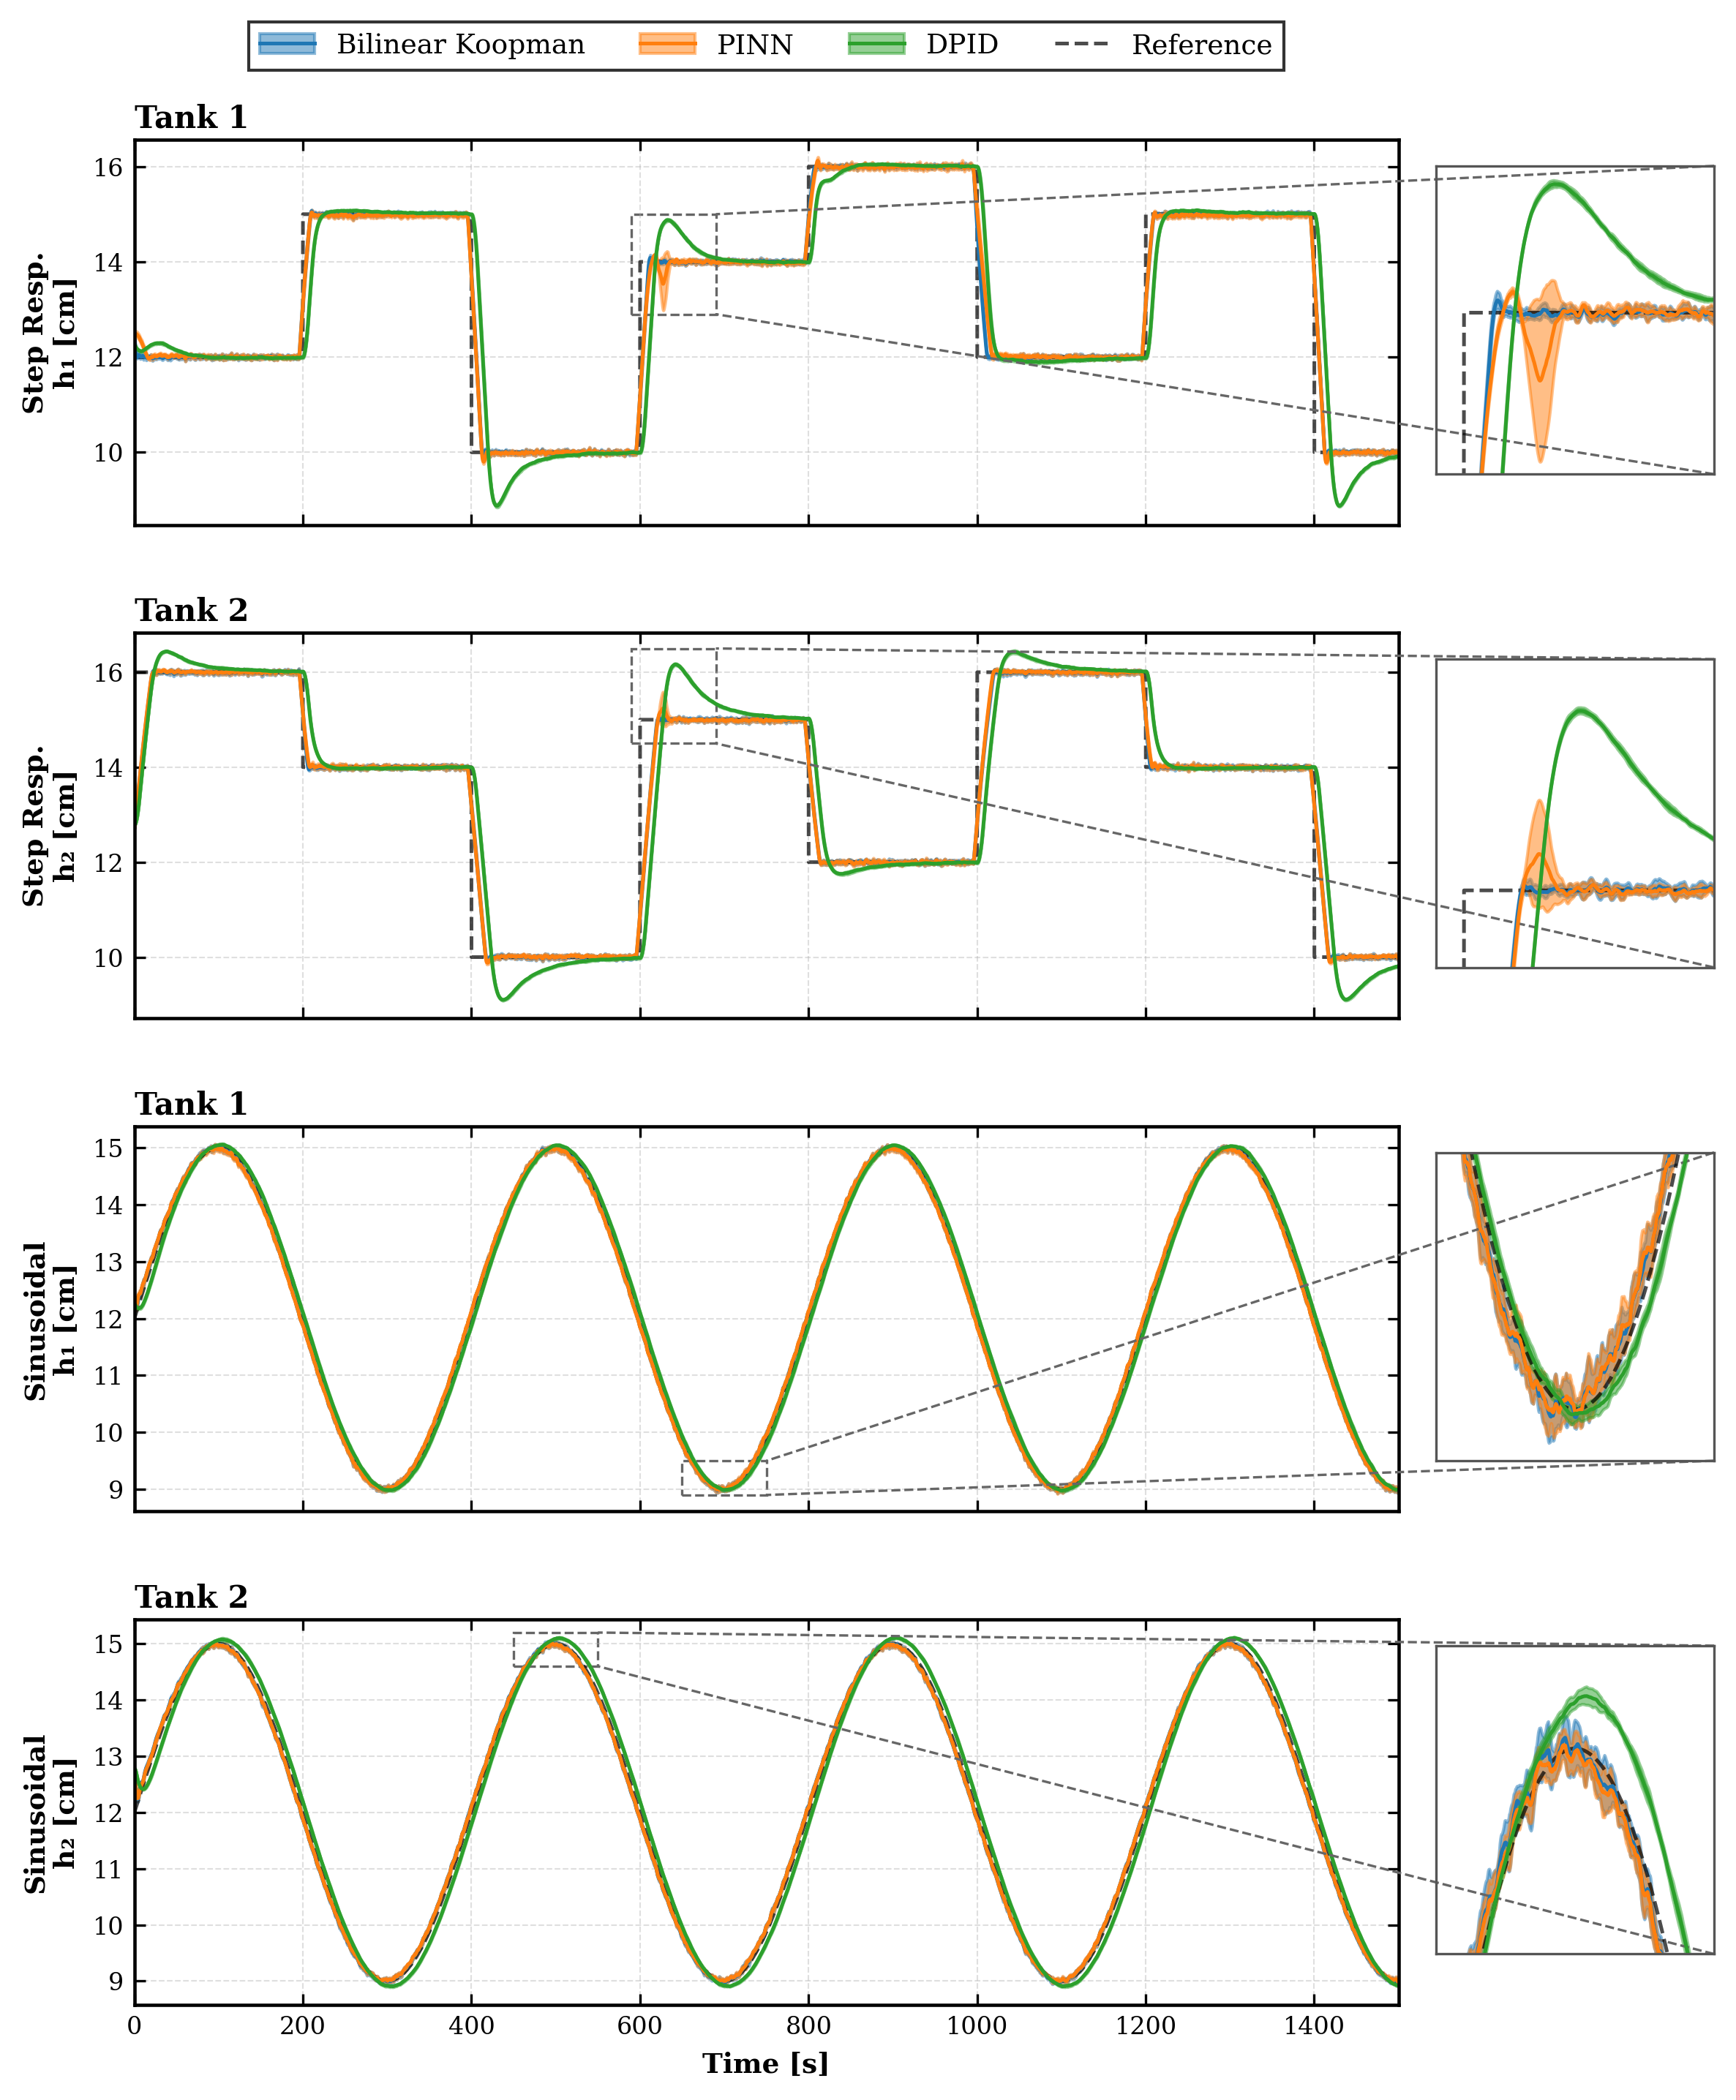

In [20]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ==========================================
# CONFIGURACIÓN ESTILO IEEE
# ==========================================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.linewidth": 1.1,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.0
})

# Mapeo explícito para las 4 filas consecutivas de la columna única
# Cada tupla contiene: (índice de fila, tipo de referencia, ID de tanque interno, etiqueta Y, título superior)
config_filas = [
    (0, 'step', 1, 'Step Resp.\nh₁ [cm]', 'Tank 1'),
    (1, 'step', 2, 'Step Resp.\nh₂ [cm]', 'Tank 2'),
    (2, 'sinusoidal', 1, 'Sinusoidal\nh₁ [cm]', 'Tank 1'),
    (3, 'sinusoidal', 2, 'Sinusoidal\nh₂ [cm]', 'Tank 2')
]

colores = {
    'Koopman': {'linea': '#1f77b4', 'sombra': '#1f77b4'},  # Azul
    'PINN':    {'linea': '#ff7f0e', 'sombra': '#ff7f0e'},  # Naranja
    'DPID':    {'linea': '#2ca02c', 'sombra': '#2ca02c'}   # Verde
}

# ==========================================
# 1. PROCESAMIENTO GLOBAL DE DATOS
# ==========================================
datos_completos = {}
tipos_referencia = ['step', 'sinusoidal']

for ref_type in tipos_referencia:
    archivos_koopman = sorted(glob.glob(f'bilinear_koopman_nmpc_results_{ref_type}_*.csv'))
    archivos_pinn    = sorted(glob.glob(f'pinn_nmpc_results_{ref_type}_*.csv'))
    archivos_pid     = sorted(glob.glob(f'linear_taylor_pid_results_{ref_type}_*.csv'))

    config_metodos = {
        'Koopman': {'archivos': archivos_koopman, 'col_h1': 'h1_bilinear_koopman_nmpc', 'col_h2': 'h2_bilinear_koopman_nmpc'},
        'PINN':    {'archivos': archivos_pinn,    'col_h1': 'h1_pinn_nmpc',    'col_h2': 'h2_pinn_nmpc'},
        'DPID':    {'archivos': archivos_pid,     'col_h1': 'h1_real_pid',     'col_h2': 'h2_real_pid'}
    }

    df_base = pd.read_csv(archivos_koopman[0])
    t_test = df_base['Time_s'].values
    h1_ref = df_base['h1_ref'].values
    h2_ref = df_base['h2_ref'].values

    stats = {}
    for metodo, config in config_metodos.items():
        h1_exp, h2_exp = [], []
        for archivo in config['archivos']:
            df = pd.read_csv(archivo)
            h1_exp.append(df[config['col_h1']].values[:len(t_test)])
            h2_exp.append(df[config['col_h2']].values[:len(t_test)])
            
        stats[metodo] = {
            'h1_mean': np.mean(h1_exp, axis=0), 'h1_std': np.std(h1_exp, axis=0),
            'h2_mean': np.mean(h2_exp, axis=0), 'h2_std': np.std(h2_exp, axis=0)
        }
        
    datos_completos[ref_type] = {
        't_test': t_test, 'h1_ref': h1_ref, 'h2_ref': h2_ref, 'stats': stats
    }

# ==========================================
# 2. CONFIGURACIÓN DE LUPAS (PROYECTADAS A LA DERECHA)
# ==========================================
# Usamos bbox_to_anchor para desplazar la lupa horizontalmente hacia afuera (lado derecho)
config_lupas = {
    'step': {
        1: {'xlim': (590, 690), 'ylim': (12.9, 15.0), 'width': "22%", 'height': "80%", 'bbox': (1.02, 0.1, 1.0, 1.0)},
        2: {'xlim': (590, 690), 'ylim': (14.5, 16.5), 'width': "22%", 'height': "80%", 'bbox': (1.02, 0.1, 1.0, 1.0)}
    },
    'sinusoidal': {
        1: {'xlim': (650, 750), 'ylim': (8.9, 9.5),  'width': "22%", 'height': "80%", 'bbox': (1.02, 0.1, 1.0, 1.0)},
        2: {'xlim': (450, 550), 'ylim': (14.6, 15.2), 'width': "22%", 'height': "80%", 'bbox': (1.02, 0.1, 1.0, 1.0)}
    }
}

# ==========================================
# 3. GENERACIÓN DE LA MATRIZ DE GRÁFICAS 4x1
# ==========================================
# sharex=True para mantener el alineamiento del tiempo en el eje horizontal
fig, axs = plt.subplots(4, 1, figsize=(9, 10), sharex=True, dpi=300)

line_handles = {}
shadow_handles = {}

for row_idx, ref_type, id_tanque, ylabel, title_tank in config_filas:
    ax = axs[row_idx]
    data_ctx = datos_completos[ref_type]
    t = data_ctx['t_test']
    
    ref_signal = data_ctx['h1_ref'] if id_tanque == 1 else data_ctx['h2_ref']
    stats_metodos = data_ctx['stats']
    
    # --- Gráfica Principal ---
    h_ref, = ax.plot(t, ref_signal, 'k--', alpha=0.7, linewidth=1.2)
    line_handles['Reference'] = h_ref
    
    for metodo, datos in stats_metodos.items():
        mean_key = f'h{id_tanque}_mean'
        std_key  = f'h{id_tanque}_std'
        
        h_line, = ax.plot(t, datos[mean_key], color=colores[metodo]['linea'], linewidth=1.2)
        h_shadow = ax.fill_between(t, datos[mean_key] - datos[std_key], datos[mean_key] + datos[std_key], 
                                   color=colores[metodo]['sombra'], alpha=0.50)
        
        label_name = 'Bilinear Koopman' if metodo == 'Koopman' else ('DPID' if metodo == 'DPID' else 'PINN')
        line_handles[label_name] = h_line
        shadow_handles[label_name] = h_shadow

    # Formateo de rejilla y límites internos estilo IEEE
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    ax.tick_params(direction='in', top=True, right=True)
    ax.set_xlim(0, 1500)
    
    # Textos por cada panel vertical
    ax.set_ylabel(ylabel, fontweight='bold')
    
    # El título del tanque va directo como título de cada panel
    ax.set_title(title_tank, fontsize=10, fontweight='bold', loc='left', pad=4)
    
    # El eje del tiempo solo va en la última gráfica de abajo
    if row_idx == 3:
        ax.set_xlabel('Time [s]', fontweight='bold')

    # --- Inyección de Lupa Externa Lateral (Derecha) ---
    zoom_cfg = config_lupas[ref_type][id_tanque]
    if zoom_cfg is not None:
        # Ubicamos la lupa usando bbox_to_anchor a la derecha (coordenada X > 1.0)
        ax_inset = inset_axes(ax, width=zoom_cfg['width'], height=zoom_cfg['height'], 
                              bbox_to_anchor=zoom_cfg['bbox'], bbox_transform=ax.transAxes, loc='lower left')
        
        ax_inset.plot(t, ref_signal, 'k--', alpha=0.7, linewidth=1.2)
        for metodo, datos in stats_metodos.items():
            mean_key = f'h{id_tanque}_mean'
            std_key  = f'h{id_tanque}_std'
            ax_inset.plot(t, datos[mean_key], color=colores[metodo]['linea'], linewidth=1.2)
            ax_inset.fill_between(t, datos[mean_key] - datos[std_key], datos[mean_key] + datos[std_key], 
                                  color=colores[metodo]['sombra'], alpha=0.50)
        
        ax_inset.set_xlim(zoom_cfg['xlim'])
        ax_inset.set_ylim(zoom_cfg['ylim'])
        
        # Limpieza de ticks de la lupa
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
        ax_inset.set_xticklabels([])
        ax_inset.set_yticklabels([])
        ax_inset.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
        ax_inset.tick_params(direction='in', top=True, right=True)
        
        for spine in ax_inset.spines.values():
            spine.set_edgecolor('#555555')
            spine.set_linewidth(0.8)
        
        # Conectores hacia el bloque extruido lateral
        mark_inset(ax, ax_inset, loc1=1, loc2=4, fc="none", ec="0.4", linestyle="--", linewidth=0.8)

# Ajuste fino de márgenes (Damos un margen derecho amplio ('right=0.76') para que quepan las lupas laterales)
plt.subplots_adjust(hspace=0.28, top=0.92, bottom=0.07, left=0.12, right=0.76)

# ==========================================
# 4. LEYENDA GLOBAL SUPERIOR
# ==========================================
legend_handles = [
    (line_handles['Bilinear Koopman'], shadow_handles['Bilinear Koopman']),
    (line_handles['PINN'], shadow_handles['PINN']),
    (line_handles['DPID'], shadow_handles['DPID']),
    line_handles['Reference']
]

legend_labels = ['Bilinear Koopman', 'PINN', 'DPID', 'Reference']

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='upper center', 
    bbox_to_anchor=(0.44, 0.98),  # Centrado respecto al bloque principal de las gráficas
    ncol=4,
    fontsize=9,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    fancybox=False
)

# Guardar vectorizado
plt.savefig('combined_control_results_4x1.pdf', bbox_inches='tight')
# Mostrar en pantalla
plt.show()